# Lab 02: Descriptive Statistics 
**CMPSC 105: Data Exploration**

## Objective
In this lab, we will move beyond calculating statistics by hand and use Python to explore a real dataset. We will compute measures of central tendency (mean, median), measures of spread (variance, standard deviation), and visualize how these numbers map to the actual shape of the data using histograms.

Name(s): Kyle McConnell and George Asante

In [1]:
# Import our standard scientific computing and visualization libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Palmer Penguins dataset
penguins = sns.load_dataset("penguins")

# Drop missing values to keep our initial calculations clean
penguins = penguins.dropna()

# Show the first 5 rows to understand the data structure
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


---
## Part 1: Mean, Median, and Quantiles

Let's investigate the `body_mass_g` column. We want to find the typical weight of a penguin in this dataset, as well as how the weights are distributed across percentiles.

In [2]:
# 1. Calculate the mean and median of the body_mass_g column
mass_mean = penguins['body_mass_g'].mean()
mass_median = penguins['body_mass_g'].median()

print(f"Mean Body Mass: {mass_mean:.2f} g")
print(f"Median Body Mass: {mass_median:.2f} g")

Mean Body Mass: 4207.06 g
Median Body Mass: 4050.00 g


In [3]:
# 2. Calculate the 0th, 25th, 50th, 75th, and 100th quantiles
quantiles = penguins['body_mass_g'].quantile([0.0, 0.25, 0.50, 0.75, 1.0])
print("Quantiles:")
print(quantiles)

Quantiles:
0.00    2700.0
0.25    3550.0
0.50    4050.0
0.75    4775.0
1.00    6300.0
Name: body_mass_g, dtype: float64


**Checkpoint:** 
> With your partner, explain out loud: *Look at the output of your 50th quantile (0.50). Why does this number exactly match the median you calculated in the cell above?*

---
## Part 2: Histograms and the "Pull" of Skew

Numbers only tell part of the story. Let's visualize the distribution of penguin weights and plot our mean and median directly on top of the data.

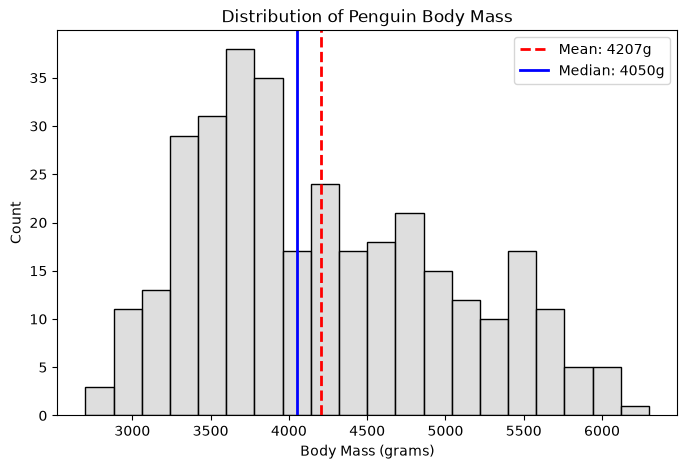

In [4]:
# Create a histogram of body mass
plt.figure(figsize=(8, 5))
sns.histplot(data=penguins, x='body_mass_g', bins=20, color='lightgray')

# Add vertical lines for the mean and median
plt.axvline(mass_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mass_mean:.0f}g')
plt.axvline(mass_median, color='blue', linestyle='-', linewidth=2, label=f'Median: {mass_median:.0f}g')

# Add labels and legend
plt.title('Distribution of Penguin Body Mass')
plt.xlabel('Body Mass (grams)')
plt.ylabel('Count')
plt.legend()
plt.show()

---
## Part 3: Variance and Standard Deviation

Now, let's look at the spread of the data. We will compare the `flipper_length_mm` of two specific species: the **Adelie** and the **Gentoo**.

In [5]:
# Filter the dataset for just Adelie and Gentoo penguins
adelie = penguins[penguins['species'] == 'Adelie']
gentoo = penguins[penguins['species'] == 'Gentoo']

# Calculate Variance
print(f"Adelie Flipper Variance: {adelie['flipper_length_mm'].var():.2f}")
print(f"Gentoo Flipper Variance: {gentoo['flipper_length_mm'].var():.2f}\n")

# Calculate Standard Deviation
print(f"Adelie Flipper Std Dev: {adelie['flipper_length_mm'].std():.2f} mm")
print(f"Gentoo Flipper Std Dev: {gentoo['flipper_length_mm'].std():.2f} mm")

Adelie Flipper Variance: 42.53
Gentoo Flipper Variance: 43.37

Adelie Flipper Std Dev: 6.52 mm
Gentoo Flipper Std Dev: 6.59 mm


In [ ]:
# Let's verify the spread visually using overlapping histograms
plt.figure(figsize=(8, 5))

# We use the original dataset but filter it inside the plot function for the hue
sns.histplot(
    data=penguins[penguins['species'].isin(['Adelie', 'Gentoo'])], 
    x='flipper_length_mm', 
    hue='species', 
    bins=15, 
    alpha=0.6
)

plt.title('Flipper Length Distribution: Adelie vs. Gentoo')
plt.xlabel('Flipper Length (mm)')
plt.show()

---
## Part 4: Questions

Double-click this cell to edit it and write your answers below. This reflection is a required part of your lab submission.

**Question 1:** If you discovered that the researchers' scale was broken and accidentally recorded one single penguin as weighing 50,000 grams instead of 5,000 grams, which descriptive statistic (the mean or the median) would change the most? Why?
* **Your Answer:** The mean would change more because the median is less affected by the outlier of 50,000 grams. The mean is an average, so the mean would vary a large amount from its true value given the new 50,000 gram value.


**Question 2:** Look at your calculations in Part 3. The variance for Gentoo flipper length is a large number (~42), while the standard deviation is much smaller (~6.5). When trying to explain the spread of the data to someone who hasn't taken a statistics class, why is the standard deviation easier to explain than the variance? *(Hint: Think about the units of measurement!)*
* **Your Answer:** Standard deviation is easier to explain because the calculation for variance makes the units mm^2, and the calculation for standard deviation brings the units back to the original measurement of mm. It would be much more difficult to explain the data to someone using a squared unit of measurement.

**Question 3:** How would the presence of an outlier, such as a penguin with an extremely high or low flipper length, affect the mean and the median? Which measure of central tendency is more robust to outliers? Why?
* **Your Answer:** [Type your answer here]